In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

## Abstract
Instead of a static NPV, as mentioned in our standard error analysis we can instead model our plant as a dynamic NPV instead. This allows us to simulate different profitability scenarios of our plant


The stochastic drivers (of this monte carlo process) are defined as follows:

1) product throughput
2) price of iBAP (varies every 5 years) - since it is likely that most companies would want to guarrantee buying capacity, most companies would do so by fulfiling long term contracts
3) price of Raw materials (bundled together) - Since most raw materials are tied to fuel price, we can lend some of the characteristics from fuel



# More detailed information for each

- Since iBAP pricing data is not obtainable, we can instead using an economical relationship between iBAP and crude oil to obtain the stochastic properties of the iBAP pricing. For simplicity we assume that crude oil makes up 40% of the input price of iBAP, hence, volatility introduced to iBAP would be the formula as follows 

Note that LiBAP is Log iBAP and LCrudeOil is Log Crude Oil

Var(LiBAP) = Var (0.4 * LCrudeoil) =   0.4^2 * 0.048 = 0.087635 ^2
Var(LHF) = 0.2^2 * Var(LCrudeOil) = 0.043838 ^2



- Based on our engineering intuition, we estimate the throughput will have a variance of about 5% of its targeted throughput. Therefore we model the throughput as N~ (578880, 170.129 ^ 2).




In [2]:
# Reading in data
crude_oil = pd.read_csv("data/crude_oil_prices.csv", parse_dates=["Date"])

# Working in log space of value
crude_oil["Value"] = np.log(crude_oil["Value"])

In [3]:
# We start by defining the stochastic drivers


# Since one of the stochastic drivers is the price in which we sell iBAP, we can capture the variance of this by benchmarking
# this to the variance of crude oil


# Make sure the data is sorted by time
crude_oil["Date"] = pd.to_datetime(crude_oil["Date"])
crude_oil = crude_oil.sort_values("Date").reset_index(drop=True)

# Choose your rolling window size (example: 30 observations)
window = 30

# Sample variance of Price on a rolling basis
crude_oil["rolling_sample_variance"] = crude_oil["Value"].rolling(window=window).var(ddof=1)

crude_oil[["Date", "Value", "rolling_sample_variance"]].head()



,Date,Value,rolling_sample_variance
0,1946-01-01,3.044999,NaN
1,1946-02-01,3.050220,NaN
2,1946-03-01,3.039271,NaN
3,1946-04-01,3.116178,NaN
4,1946-05-01,3.110399,NaN


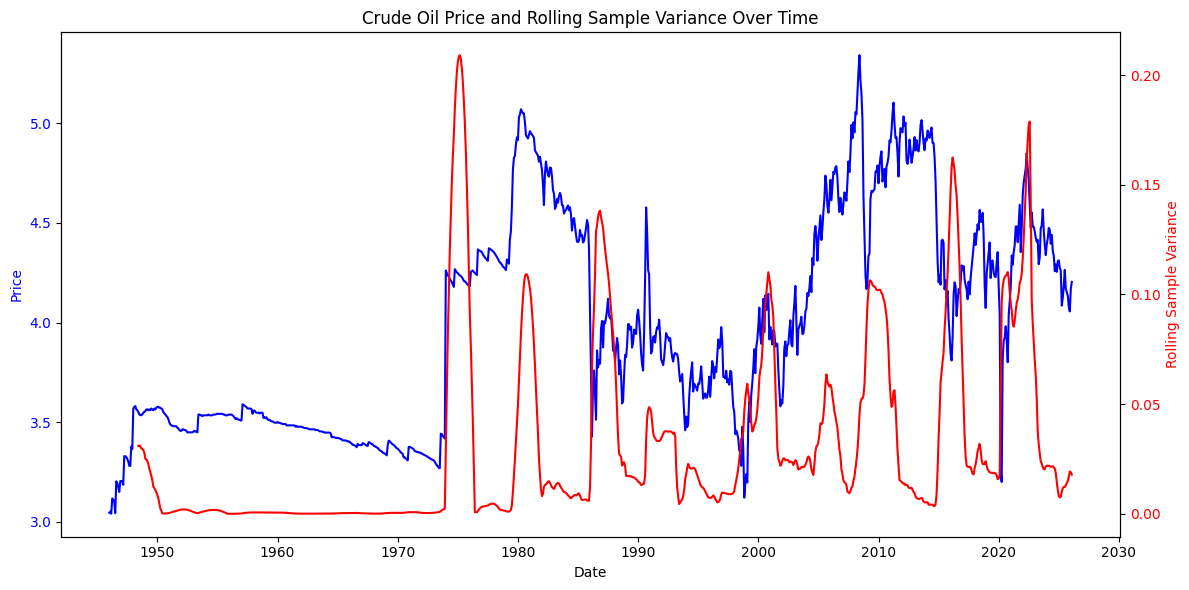

In [4]:
# crude_oil["rolling_sample_variance"].value_counts() 
# crude_oil["rolling_sample_variance"].mean() 
# crude_oil["Value"].mean()


fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Price on left y-axis
ax1.plot(crude_oil["Date"], crude_oil["Value"], label="Price", color="blue")
ax1.set_xlabel("Date")
ax1.set_ylabel("Price", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Plot rolling sample variance on right y-axis
ax2 = ax1.twinx()
ax2.plot(
    crude_oil["Date"],
    crude_oil["rolling_sample_variance"],
    label="Rolling Sample Variance",
    color="red"
)
ax2.set_ylabel("Rolling Sample Variance", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Crude Oil Price and Rolling Sample Variance Over Time")
fig.tight_layout()
plt.show()


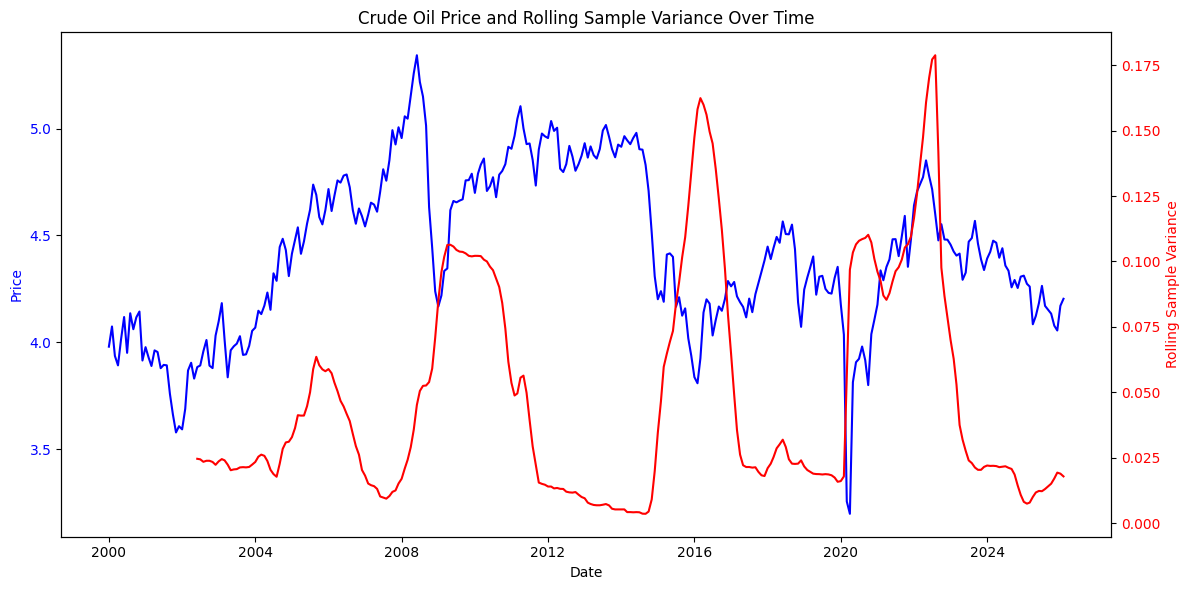

In [5]:
# Remove all rows before year 2000
crude_oil = crude_oil[crude_oil["Date"].dt.year >= 2000].reset_index(drop=True)
# Choose your rolling window size (example: 30 observations)
window = 30

# Sample variance of Value on a rolling basis
crude_oil["rolling_sample_variance"] = crude_oil["Value"].rolling(window=window).var(ddof=1)

crude_oil[["Date", "Value", "rolling_sample_variance"]].head()
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Price on left y-axis
ax1.plot(crude_oil["Date"], crude_oil["Value"], label="Price", color="blue")
ax1.set_xlabel("Date")
ax1.set_ylabel("Price", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Plot rolling sample variance on right y-axis
ax2 = ax1.twinx()
ax2.plot(
    crude_oil["Date"],
    crude_oil["rolling_sample_variance"],
    label="Rolling Sample Variance",
    color="red"
)
ax2.set_ylabel("Rolling Sample Variance", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Crude Oil Price and Rolling Sample Variance Over Time")
fig.tight_layout()
plt.show()

In [6]:
print(crude_oil["rolling_sample_variance"].mean())
print(crude_oil["Value"].mean())
print(math.sqrt(crude_oil["rolling_sample_variance"].mean()))

0.04804630482115615
4.420392389467421
0.21919467334120177


# Defining Stochastic Drivers

The mean of crude_oil sits around 89.16 while the S.E estimator is 19.8037. The 